# Baseline models

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
df.drop(columns = ["Unnamed: 0_x"], inplace = True)
df.drop(columns = ["Unnamed: 0_y"], inplace = True)

In [4]:
df.dropna(inplace = True)

In [5]:
df.drop(columns = ["rr"], inplace = True)
df.drop(columns = ["clasi_rr"], inplace = True)

In [6]:
df.drop(columns = ["rr_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_lag_1"], inplace = True)
df.drop(columns = ["rr_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_lag_2"], inplace = True)
df.drop(columns = ["rr_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_lag_3"], inplace = True)
df.drop(columns = ["rr_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_lag_4"], inplace = True)
df.drop(columns = ["rr_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_lag_5"], inplace = True)
df.drop(columns = ["rr_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_lag_6"], inplace = True)
df.drop(columns = ["rr_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_lag_7"], inplace = True)
df.drop(columns = ["rr_lag_8"], inplace = True)
df.drop(columns = ["clasi_rr_lag_8"], inplace = True)

In [7]:
df.head()

,casos,week_canton,urb,tmin_min,tmin_max,tmin_mean,tmin_median,tmax_min,tmax_max,tmax_mean,...,precip_median_lag_2,precip_median_lag_1,precip_min_lag_8,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,1,16.785858,20.006693,18.775265,19.645410,26.733393,28.077051,27.372263,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,2,2020-10-101,1,17.235245,19.964815,18.723231,18.793407,26.638765,28.377457,27.568323,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,2,2020-11-101,1,18.474545,19.621017,19.110772,19.157510,27.162430,27.981869,27.610641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0,2020-12-101,1,18.497475,19.358017,18.967383,19.099348,26.924604,27.665537,27.361927,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.377879,0.0,0.0
4,0,2020-13-101,1,17.836336,19.390366,18.653528,18.680185,27.018480,28.346085,27.606657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [8]:
df.shape

(20817, 146)

In [9]:
df = pd.get_dummies(df, columns = ["urb"])

In [10]:
df.head()

,casos,week_canton,tmin_min,tmin_max,tmin_mean,tmin_median,tmax_min,tmax_max,tmax_mean,tmax_median,...,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1,urb_0,urb_1,urb_2
0,4,2020-9-101,16.785858,20.006693,18.775265,19.645410,26.733393,28.077051,27.372263,27.085123,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,False,True,False
1,2,2020-10-101,17.235245,19.964815,18.723231,18.793407,26.638765,28.377457,27.568323,27.866480,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,False,True,False
2,2,2020-11-101,18.474545,19.621017,19.110772,19.157510,27.162430,27.981869,27.610641,27.503464,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,False,True,False
3,0,2020-12-101,18.497475,19.358017,18.967383,19.099348,26.924604,27.665537,27.361927,27.434515,...,0.0,0.0,0.0,0.0,4.377879,0.0,0.0,False,True,False
4,0,2020-13-101,17.836336,19.390366,18.653528,18.680185,27.018480,28.346085,27.606657,27.502207,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,False,True,False


In [11]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["casos", "week_canton"])
y_train = train['casos']

X_val = val.drop(columns = ["casos", "week_canton"])
y_val= val['casos']

X_test= test.drop(columns = ["casos", "week_canton"])
y_test = test['casos']

In [12]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [13]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [14]:
train.shape, val.shape, test.shape

((14013, 148), (3726, 148), (3078, 148))

## Case number
### Linear regression

In [26]:
reg = LinearRegression().fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [27]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_for_reg, y_pred_reg)
rmse_reg = mse_reg ** 0.5

In [28]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
MSE reg: {round(mse_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.913
MAE reg: 1.943
MSE reg: 19.886
RMSE reg: 4.459
      


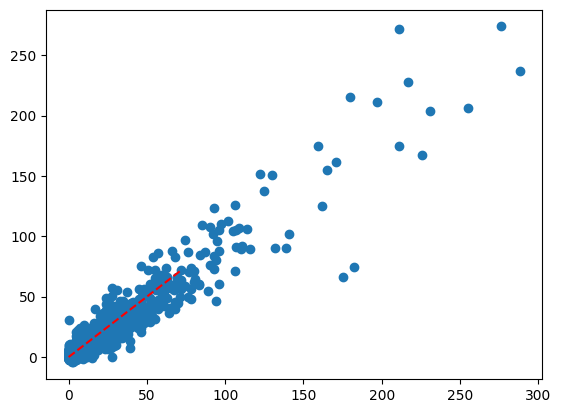

In [29]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_reg)

In [30]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False)

coef_reg_sorted

,Feature,Coefficient,Std,Coefficient_std
22,casos_lag_1,9.041522,1.000036,9.041844
100,nino34ssta_lag_3,7.096746,1.000036,7.096999
13,nino34ssta,3.978100,1.000036,3.978242
96,nino34ssta_lag_7,3.813160,1.000036,3.813296
2,tmin_mean,3.623281,1.000036,3.623410
...,...,...,...,...
45,tmax_mean_lag_2,-3.095855,1.000036,-3.095966
99,nino34ssta_lag_4,-3.397154,1.000036,-3.397275
98,nino34ssta_lag_5,-3.523442,1.000036,-3.523568
78,tmin_mean_lag_1,-3.548931,1.000036,-3.549058


Text(0.5, 0, 'Coefficient')

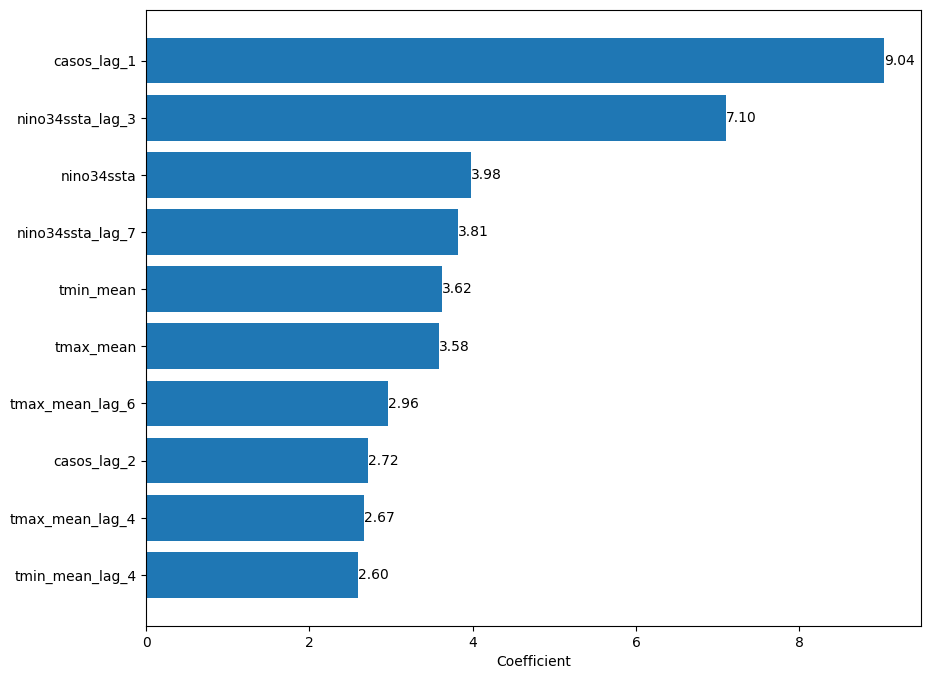

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [15]:
rf = RandomForestRegressor().fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_for_reg_scaled)

In [17]:
mae_rf = mean_absolute_error(y_test_for_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_for_reg, y_pred_rf)
rmse_rf = mse_rf ** 0.5

In [34]:
print(f"""MAE rf: {round(mae_rf, 3)}
MSE rf: {round(mse_rf, 3)}
RMSE rf: {round(rmse_rf, 3)}
      """)

MAE rf: 1.915
MSE rf: 29.483
RMSE rf: 5.43
      


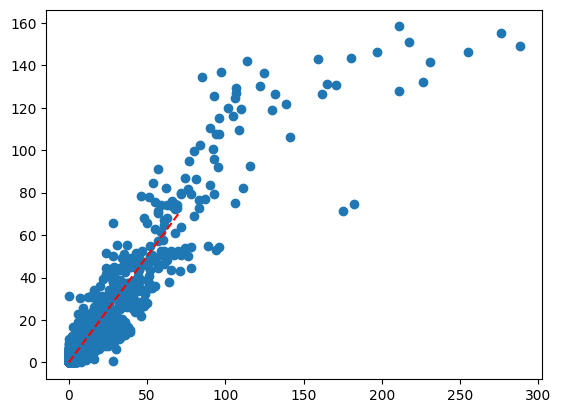

In [19]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_rf)

In [20]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
22,casos_lag_1,0.878279
21,casos_lag_2,0.008484
113,precip_max_lag_6,0.003364
20,casos_lag_3,0.002907
19,casos_lag_4,0.002412
...,...,...
141,precip_min_lag_2,0.000110
145,urb_2,0.000105
143,urb_0,0.000103
144,urb_1,0.000098


Text(0.5, 0, 'Importance')

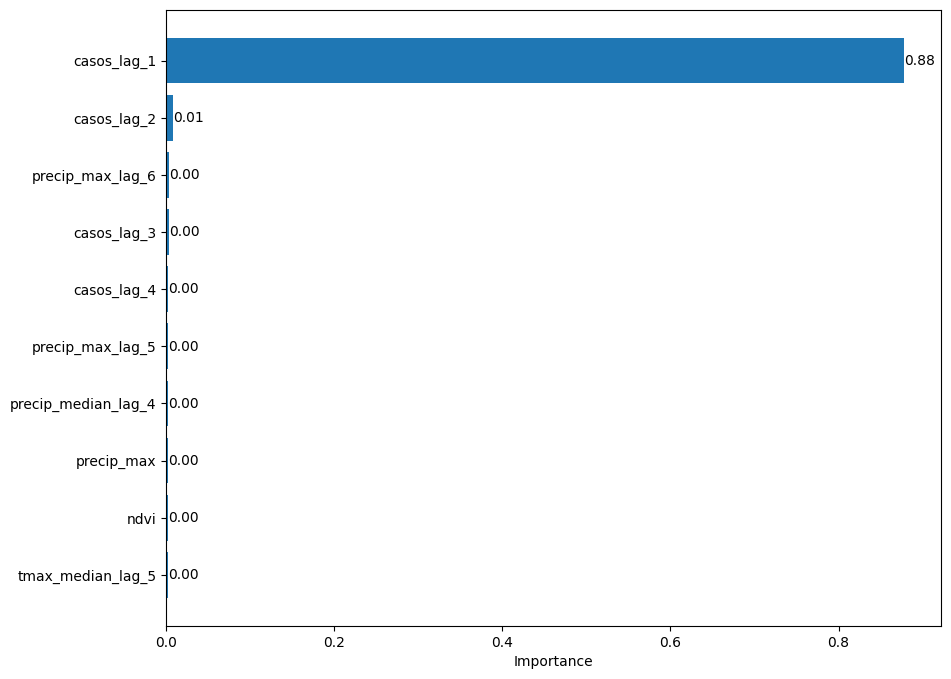

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")